# Zomato Restaurants Data — Cleaning & Preprocessing Pipeline



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 160)
plt.rcParams['figure.figsize'] = (8, 4)


## 1. Load & Inspect

In [4]:
df = pd.read_csv('zomato.csv', encoding='latin-1')
print("Shape:", df.shape)
df.head()


Shape: (9551, 21)


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [7]:
df = df.drop(columns=[
    'Longitude',
    'Latitude',
])

print("Columns after dropping:")
print(df.columns.tolist())

Columns after dropping:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']


In [8]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])


Missing values per column:
Cuisines    9
dtype: int64


## 2. Clean Currency Formatting


In [9]:
df['Currency'] = df['Currency'].str.replace('\x8c', '', regex=False).str.strip()

FX_TO_USD = {
    'Indian Rupees(Rs.)': 0.012, 'Dollar($)': 1.0, 'Pounds(£)': 1.27,
    'Brazilian Real(R$)': 0.19, 'Emirati Diram(AED)': 0.27, 'Rand(R)': 0.055,
    'NewZealand($)': 0.61, 'Turkish Lira(TL)': 0.031, 'Botswana Pula(P)': 0.074,
    'Indonesian Rupiah(IDR)': 0.000064, 'Qatari Rial(QR)': 0.27, 'Sri Lankan Rupee(LKR)': 0.0031,
}
df['fx_to_usd'] = df['Currency'].map(FX_TO_USD)
df['Average Cost for two (USD)'] = (df['Average Cost for two'] * df['fx_to_usd']).round(2)

print("Unmapped currencies:", df['fx_to_usd'].isna().sum())
df[['Currency', 'Average Cost for two', 'Average Cost for two (USD)']].drop_duplicates('Currency')


Unmapped currencies: 0


,Currency,Average Cost for two,Average Cost for two (USD)
0,Botswana Pula(P),1100,81.40
22,Brazilian Real(R$),55,10.45
82,Dollar($),25,25.00
564,Emirati Diram(AED),190,51.30
624,Indian Rupees(Rs.),850,10.20
9276,Indonesian Rupiah(IDR),150000,9.60
9297,NewZealand($),40,24.40
9337,Pounds(£),10,12.70
9417,Qatari Rial(QR),150,40.50
9437,Rand(R),294,16.17


## 3. Fix Category Errors

Trim whitespace on all text columns, standardize the Yes/No casing on boolean-like flag columns,
and drop `Switch to order menu`, which turns out to be a constant column (always "No") and carries
no predictive information.

In [10]:
str_cols = df.select_dtypes(include='object').columns.tolist()
for c in str_cols:
    df[c] = df[c].astype(str).str.strip()

binary_cols = ['Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu']
for c in binary_cols:
    df[c] = df[c].str.capitalize()

print("Switch to order menu unique values:", df['Switch to order menu'].unique())
if df['Switch to order menu'].nunique() == 1:
    df = df.drop(columns=['Switch to order menu'])
    print("Dropped 'Switch to order menu' (constant column)")


Switch to order menu unique values: ['No']
Dropped 'Switch to order menu' (constant column)


## 4. Impute Missing Values

Only `Cuisines` has missing values (9 rows). We fill these with `'Unknown'` rather than dropping the rows,
since every other field for those restaurants is still valid and usable.

In [11]:
df['Cuisines'] = df['Cuisines'].replace('nan', np.nan)
print("Missing Cuisines before impute:", df['Cuisines'].isnull().sum())

df['Cuisines'] = df['Cuisines'].fillna('Unknown')
print("Missing Cuisines after impute:", df['Cuisines'].isnull().sum())
print("Total remaining missing values in dataset:", df.isnull().sum().sum())


Missing Cuisines before impute: 9
Missing Cuisines after impute: 0
Total remaining missing values in dataset: 0


## 5. Remove Duplicates

In [12]:
before = len(df)
df = df.drop_duplicates(subset='Restaurant ID', keep='first')
df = df.drop_duplicates()
print(f"Rows before: {before}, after: {len(df)}, removed: {before - len(df)}")


Rows before: 9551, after: 9551, removed: 0


## 6. Outlier Handling (IQR Capping)

`Votes` and the new `Average Cost for two (USD)` are both heavily right-skewed (a handful of very
high-traffic or very expensive restaurants). We cap values outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`
rather than deleting rows, so we keep every restaurant but limit the influence of extreme values.

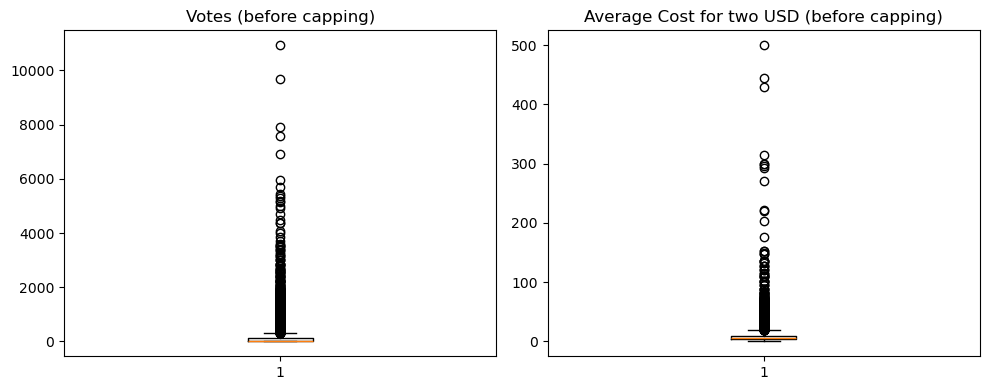

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df['Votes'])
axes[0].set_title('Votes (before capping)')
axes[1].boxplot(df['Average Cost for two (USD)'])
axes[1].set_title('Average Cost for two USD (before capping)')
plt.tight_layout()
plt.show()


In [14]:
# df = df.drop(columns=[
#     'Longitude',
#     'Latitude',
#     'Currency_enc'
# ])



In [15]:
def iqr_cap(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return series.clip(lower, upper)

for col in ['Votes', 'Average Cost for two (USD)']:
    before_max = df[col].max()
    df[col] = iqr_cap(df[col])
    print(f"{col}: max {before_max} -> {df[col].max()}")


Votes: max 10934 -> 320
Average Cost for two (USD): max 500.0 -> 19.6


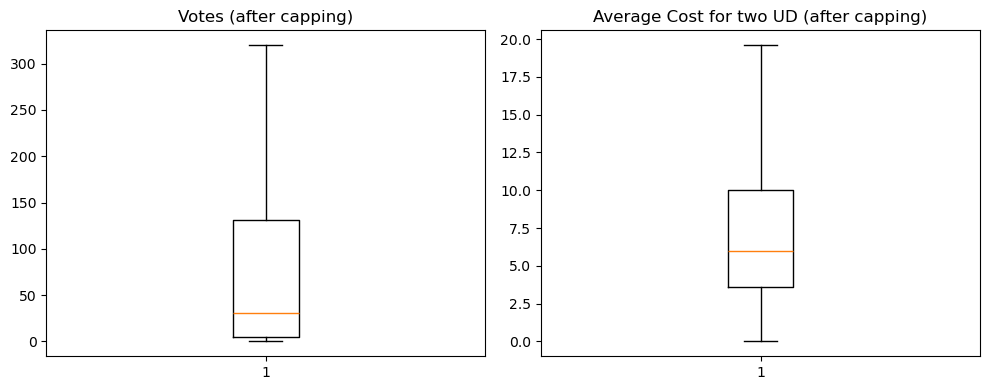

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].boxplot(df['Votes'])
axes[0].set_title('Votes (after capping)')
axes[1].boxplot(df['Average Cost for two (USD)'])
axes[1].set_title('Average Cost for two UD (after capping)')
plt.tight_layout()
plt.show()


## 7. Label Encoding

Encode categorical columns into integers for modeling. We keep the original text columns alongside
the `_enc` versions so the data stays human-readable.

In [17]:
encoders = {}
cat_cols = ['City', 'Currency', 'Has Table booking', 'Has Online delivery',
            'Is delivering now', 'Rating color', 'Rating text']

for c in cat_cols:
    le = LabelEncoder()
    df[c + '_enc'] = le.fit_transform(df[c])
    encoders[c] = dict(zip(le.classes_, le.transform(le.classes_).tolist()))

print("New encoded columns:", [c + '_enc' for c in cat_cols])
df[['Rating text', 'Rating text_enc']].drop_duplicates().sort_values('Rating text_enc')


New encoded columns: ['City_enc', 'Currency_enc', 'Has Table booking_enc', 'Has Online delivery_enc', 'Is delivering now_enc', 'Rating color_enc', 'Rating text_enc']


,Rating text,Rating text_enc
22,Average,0
0,Excellent,1
15,Good,2
30,Not rated,3
312,Poor,4
2,Very Good,5


## 8. Class Balance Check

`Rating text` is the natural categorical read-out of the rating. It's noticeably imbalanced —
"Average" dominates, while "Poor" and "Excellent" are rare, and ~22% of restaurants have never
been rated at all (`Aggregate rating == 0`). This matters if the rating is later framed as a
classification problem, and it's also why the regression target below excludes unrated restaurants.

             count   pct
Rating text             
Average       3737  39.1
Not rated     2148  22.5
Good          2100  22.0
Very Good     1079  11.3
Excellent      301   3.2
Poor           186   1.9


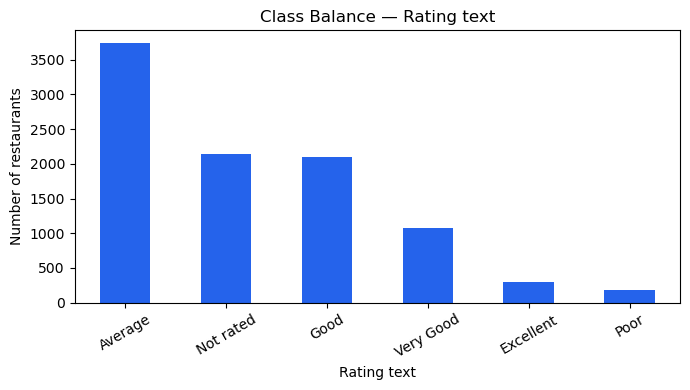

In [18]:
counts = df['Rating text'].value_counts()
pct = (df['Rating text'].value_counts(normalize=True) * 100).round(1)
print(pd.DataFrame({'count': counts, 'pct': pct}))

plt.figure(figsize=(7, 4))
counts.plot(kind='bar', color='#2563EB')
plt.title('Class Balance — Rating text')
plt.ylabel('Number of restaurants')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 9. Feature Engineering

New features built from existing columns:
- **Primary Cuisine**: first cuisine listed (restaurants often list several)
- **Num Cuisines**: how many cuisines a restaurant offers
- **Is Rated**: whether the restaurant has any votes/rating yet (`Aggregate rating > 0`)
- **Votes (log)**: log-transformed votes to tame remaining skew
- **City Restaurant Count**: how many restaurants in the dataset share that city (proxy for market density)

In [19]:
df['Primary Cuisine'] = df['Cuisines'].apply(lambda x: x.split(',')[0].strip())
df['Num Cuisines'] = df['Cuisines'].apply(lambda x: len(x.split(',')))
df['Is Rated'] = (df['Aggregate rating'] > 0).astype(int)
df['Votes (log)'] = np.log1p(df['Votes'])

city_counts = df['City'].value_counts()
df['City Restaurant Count'] = df['City'].map(city_counts)

le_prim = LabelEncoder()
df['Primary Cuisine_enc'] = le_prim.fit_transform(df['Primary Cuisine'])
encoders['Primary Cuisine'] = dict(zip(le_prim.classes_, le_prim.transform(le_prim.classes_).tolist()))

df[['Primary Cuisine', 'Num Cuisines', 'Is Rated', 'Votes (log)', 'City Restaurant Count']].head()


,Primary Cuisine,Num Cuisines,Is Rated,Votes (log),City Restaurant Count
0,French,3,1,5.752573,2
1,Japanese,1,1,5.771441,2
2,Seafood,4,1,5.602119,4
3,Japanese,2,1,5.771441,4
4,Japanese,2,1,5.438079,4


## 10. Train/Test Split

We split **before** scaling to avoid data leakage (the scaler must never see the test set).
We predict `Aggregate rating` for restaurants that have actually been rated (`Is Rated == 1`) —
the ~22% of "Not rated" restaurants have no meaningful target and are excluded from modeling.

In [27]:
model_df = df[df['Is Rated'] == 1].copy()

feature_cols = ['Country Code', 'City_enc', 'Primary Cuisine_enc',
                 'Num Cuisines', 'Average Cost for two (USD)',
                 'Has Table booking_enc', 'Has Online delivery_enc', 'Price range',
                 'Votes', 'Votes (log)', 'City Restaurant Count']
target_col = 'Aggregate rating'

X = model_df[feature_cols]
y = model_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train:", X_train.shape, " X_test:", X_test.shape)


X_train: (5922, 11)  X_test: (1481, 11)


## 11. Feature Scaling

Standardize numeric features (mean 0, std 1) using a scaler **fit only on the training set**,
then apply the same transform to the test set.

In [28]:
scaler = StandardScaler()
num_cols = X_train.columns.tolist()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

X_train_scaled.describe().loc[['mean', 'std']].round(2)


,Country Code,City_enc,Primary Cuisine_enc,Num Cuisines,Average Cost for two (USD),Has Table booking_enc,Has Online delivery_enc,Price range,Votes,Votes (log),City Restaurant Count
mean,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 12. Final Checks & Save

Final null checks, then save:
- `cleaned_zomato.csv` — full cleaned & feature-engineered dataset (all restaurants)
-  `test.csv` — scaled, model-ready splits (rated restaurants only)

In [ ]:
train_df = X_train_scaled.copy()
train_df[target_col] = y_train.values
test_df = X_test_scaled.copy()
test_df[target_col] = y_test.values

print("Nulls in train:", train_df.isnull().sum().sum())
print("Nulls in test:", test_df.isnull().sum().sum())
print("Train shape:", train_df.shape, " Test shape:", test_df.shape)

test_df.to_csv('testt.csv', index=False)
print("Saved testt.csv")


Nulls in train: 0
Nulls in test: 0
Train shape: (5922, 12)  Test shape: (1481, 12)
Saved test.csv


In [30]:
train_df.head()


,Country Code,City_enc,Primary Cuisine_enc,Num Cuisines,Average Cost for two (USD),Has Table booking_enc,Has Online delivery_enc,Price range,Votes,Votes (log),City Restaurant Count,Aggregate rating
215,3.100432,-1.771347,0.059019,-0.178338,1.829388,-0.420279,-0.691580,1.103296,0.296463,0.728023,-1.300495,3.8
2877,-0.345073,0.435384,0.592270,-0.178338,-1.316770,-0.420279,-0.691580,-1.044188,-0.815666,-0.813725,0.897288,3.7
8073,-0.345073,0.475506,-0.140950,-0.178338,-0.188257,-0.420279,1.445965,0.029554,-0.180164,0.369848,-0.873272,4.0
115,3.100432,-2.774406,0.025691,-1.062857,1.829388,-0.420279,-0.691580,1.103296,1.841086,1.339048,-1.300495,4.1
52,0.119670,1.358199,-1.174122,-1.062857,1.401921,-0.420279,-0.691580,1.103296,-0.859798,-1.036845,-1.300495,4.3
